# A* India Traffic Router — State → City → Live Path

Pre-generated CSVs for 23 cities across 15 Indian states.
Select a state → city loads instantly (no internet needed).

| Step | Cell |
|------|------|
| 1 | Install deps |
| 2 | Generate CSVs (run once) |
| 3 | Imports |
| 4 | **Launch interactive router** |
| 5 | Programmatic use |
| 6 | Congestion analysis |

## Cell 1 — Install dependencies
Run once.

In [1]:
import subprocess, sys
for p in ['matplotlib','pandas','numpy','ipywidgets','scikit-learn']:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'-q'])
    print(f'  {p} ok')
print('Done. Restart kernel if first install.')


  matplotlib ok
  pandas ok
  numpy ok
  ipywidgets ok
  scikit-learn ok
Done. Restart kernel if first install.


## Cell 2 — Generate city CSVs (run once)
Creates `india_road_data/` folder with state subfolders and city CSVs.

In [2]:
# Run the generator script (only needed once)
exec(open('generate_city_csvs.py').read())


  [Karnataka] Bengaluru                 â†’   57 rows  â†’ india_road_data\Karnataka\Bengaluru.csv
  [Karnataka] Mysuru                    â†’   40 rows  â†’ india_road_data\Karnataka\Mysuru.csv
  [Karnataka] Udupi                     â†’   40 rows  â†’ india_road_data\Karnataka\Udupi.csv
  [Karnataka] Mangaluru                 â†’   36 rows  â†’ india_road_data\Karnataka\Mangaluru.csv
  [Maharashtra] Mumbai                    â†’   44 rows  â†’ india_road_data\Maharashtra\Mumbai.csv
  [Maharashtra] Pune                      â†’   38 rows  â†’ india_road_data\Maharashtra\Pune.csv
  [Maharashtra] Nagpur                    â†’   30 rows  â†’ india_road_data\Maharashtra\Nagpur.csv
  [Tamil Nadu] Chennai                   â†’   44 rows  â†’ india_road_data\Tamil_Nadu\Chennai.csv
  [Tamil Nadu] Coimbatore                â†’   26 rows  â†’ india_road_data\Tamil_Nadu\Coimbatore.csv
  [Delhi] Delhi                     â†’   41 rows  â†’ india_road_data\Delhi\Delhi.csv
  [West Bengal] Kolkata  

## Cell 3 — Imports

In [3]:
import sys, os
sys.path.insert(0, os.getcwd())

#%%matplotlib inline

import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

from astar_router import RoadNetwork, AStarEngine, AStarVisualizer
import pandas as pd, numpy as np

print('Imports OK | backend:', plt.get_backend())


Imports OK | backend: module://matplotlib_inline.backend_inline


## Cell 4 — Interactive Router

**How to use:**
1. Select **State** from the first dropdown — city list updates automatically
2. Select **City** — only cities for that state appear
3. Click **Load City Network** — loads just that one CSV (instant, no internet)
4. **Source** and **Dest** dropdowns populate with real named junctions
5. Adjust delay slider → click **Run A\* Live** — watch every step animate

> To explore a different city: just change the dropdowns and click Load again.

In [ ]:
viz = AStarVisualizer(data_dir='india_road_data')
viz.show()


## Cell 5 — Programmatic use (no widgets)

In [4]:
# Load any city directly by state + city name
net = RoadNetwork('Maharashtra', 'Mumbai', data_dir='india_road_data')
net.summary()


  Mumbai, Maharashtra
  Nodes   : 20
  Edges   : 44
  Columns : ['u', 'v', 'key', 'name', 'highway', 'oneway', 'length', 'speed_kph', 'travel_time', 'traffic_volume', 'PCU', 'capacity', 'vc_ratio', 'congested_time', 'congestion_class', 'delay_sec', 'speed_efficiency', 'highway_code', 'length_norm', 'speed_kph_norm', 'travel_time_norm', 'traffic_volume_norm', 'PCU_norm', 'capacity_norm', 'vc_ratio_norm', 'congested_time_norm', 'u_lat', 'u_lon', 'v_lat', 'v_lon', 'u_name', 'v_name']


,u_name,v_name,name,highway,length,speed_kph,travel_time,vc_ratio,congested_time,congestion_class
0,CST Station,Lower Parel,Eastern Freeway,motorway,5000,65.0,225.0,0.833,241.28,heavy
1,CST Station,Colaba,Marine Dr,primary,3000,40.0,270.0,0.778,284.82,heavy
2,Colaba,CST Station,Marine Dr,primary,3000,40.0,270.0,0.778,284.82,heavy
3,Dadar,Bandra,Western Express Hwy,motorway,4500,65.0,202.5,0.926,224.83,heavy
4,Dadar,Worli,Sion-Bandra Link,primary,4000,50.0,288.0,1.167,368.03,gridlock
5,Worli,Dadar,Sion-Bandra Link,primary,4000,50.0,288.0,1.167,368.03,gridlock
6,Andheri,Goregaon,Link Rd,primary,3000,50.0,216.0,1.333,318.40,gridlock
7,Goregaon,Andheri,Link Rd,primary,3000,50.0,216.0,1.333,318.40,gridlock


In [5]:
# Run A* between first and middle node
all_ids = list(net.nodes.keys())
src, dst = all_ids[0], all_ids[len(all_ids)//2]
engine   = AStarEngine(net, src, dst)

sn,dn = net.nodes[src], net.nodes[dst]
print(f'From : {sn["name"]}  ({sn["lat"]:.4f},{sn["lon"]:.4f})')
print(f'To   : {dn["name"]}  ({dn["lat"]:.4f},{dn["lon"]:.4f})')
if engine.path:
    print(f'Cost : {engine.cost:.2f}s ({engine.cost/60:.2f} min)')
    print(f'Nodes: {len(engine.path)}   Steps: {len(engine.steps)}')
    print()
    for i,nid in enumerate(engine.path):
        tag = 'START' if i==0 else ('END' if i==len(engine.path)-1 else str(i))
        print(f'  [{tag:5}] {net.nodes[nid]["name"]}')
else:
    print('No path found')


From : CST Station  (18.9398,72.8354)
To   : Chembur  (19.0620,72.9006)
Cost : 2139.52s (35.66 min)
Nodes: 7   Steps: 18

  [START] CST Station
  [1    ] Lower Parel
  [2    ] Worli
  [3    ] Dadar
  [4    ] Bandra
  [5    ] Kurla
  [END  ] Chembur


## Cell 6 — Congestion analysis for any loaded city

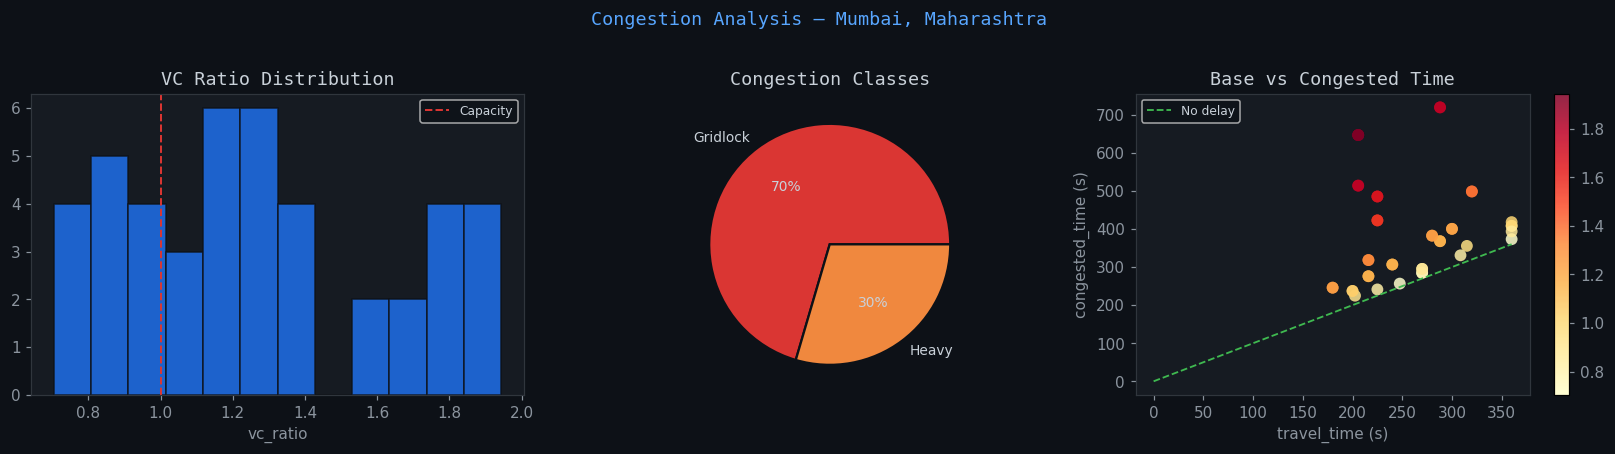

       name   highway  vc_ratio congestion_class  congested_time
   Kurla Rd secondary     1.944         gridlock          646.82
   Kurla Rd secondary     1.944         gridlock          646.82
Dr Annie Rd secondary     1.944         gridlock          646.82
Dr Annie Rd secondary     1.944         gridlock          646.82
 Ramabai Rd secondary     1.778         gridlock          513.94
 Ramabai Rd secondary     1.778         gridlock          513.94
Eastern Hwy secondary     1.778         gridlock          719.51
Eastern Hwy secondary     1.778         gridlock          719.51


In [6]:
import matplotlib.pyplot as plt

df = net.df.copy()
df['cc'] = df['vc_ratio'].apply(
    lambda v: 'Free' if v<0.4 else 'Moderate' if v<0.7 else 'Heavy' if v<1.0 else 'Gridlock')

fig, axes = plt.subplots(1,3,figsize=(15,4))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_color('#30363d')
    ax.tick_params(colors='#8b949e')

axes[0].hist(df['vc_ratio'],bins=12,color='#1f6feb',edgecolor='#0d1117',alpha=0.85)
axes[0].axvline(1.0,color='#da3633',linestyle='--',linewidth=1.3,label='Capacity')
axes[0].set_title('VC Ratio Distribution',color='#c9d1d9',fontfamily='monospace')
axes[0].set_xlabel('vc_ratio',color='#8b949e')
axes[0].legend(facecolor='#0d1117',labelcolor='#c9d1d9',fontsize=8)

cc=df['cc'].value_counts()
cols={'Free':'#3fb950','Moderate':'#d29922','Heavy':'#f0883e','Gridlock':'#da3633'}
axes[1].pie(cc.values,labels=cc.index,colors=[cols.get(c,'#58a6ff') for c in cc.index],
    autopct='%1.0f%%',textprops={'color':'#c9d1d9','fontsize':9},
    wedgeprops={'edgecolor':'#0d1117','linewidth':1.5})
axes[1].set_title('Congestion Classes',color='#c9d1d9',fontfamily='monospace')

sc=axes[2].scatter(df['travel_time'],df['congested_time'],
    c=df['vc_ratio'],cmap='YlOrRd',s=60,alpha=0.85,edgecolors='none')
mx=df['travel_time'].max()
axes[2].plot([0,mx],[0,mx],color='#3fb950',linestyle='--',linewidth=1.2,label='No delay')
axes[2].set_title('Base vs Congested Time',color='#c9d1d9',fontfamily='monospace')
axes[2].set_xlabel('travel_time (s)',color='#8b949e')
axes[2].set_ylabel('congested_time (s)',color='#8b949e')
axes[2].legend(facecolor='#0d1117',labelcolor='#c9d1d9',fontsize=8)

plt.suptitle(f'Congestion Analysis — {net.city}, {net.state}',
    color='#58a6ff',fontsize=12,fontfamily='monospace',y=1.02)
plt.colorbar(sc,ax=axes[2]).ax.tick_params(colors='#8b949e')
plt.tight_layout(); plt.show()

print(df[['name','highway','vc_ratio','congestion_class','congested_time']]
    .sort_values('vc_ratio',ascending=False).head(8).to_string(index=False))


In [7]:
import pandas as pd
df = pd.read_csv("india_road_data/Maharashtra/Mumbai.csv")
print(df["vc_ratio"].mean())          # → 1.261
print(df["delay_sec"].mean())         # → 139.55
print(df["speed_efficiency"].mean())  # → 0.714
print((df["congestion_class"] == "gridlock").mean() * 100)  # → 70.45

1.261022727272727
139.54863636363638
0.7138461162261677
70.45454545454545
